In [55]:

import sys
sys.path.append('C:\PROJECT-DEMETER\Demeter_retrain') 

from lstm import HalfOrbitPairDataset
from lstm.scaling import scale_datasets
from lstm import LSTMAutoencoder
from lstm import train_lstm_ae
from lstm import plot_encoded_representation
from lstm.anomaly_detection import AnomalyDetector
from lstm import SeismicAnomalyAnalyzer
from lstm import SeismicCriteria
from lstm import train_lstm_ae_mode
from lstm import SeismicAnalysis
from lstm import SeismicRatioEvaluator

from datetime import datetime

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import os
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import random
import seaborn as sns
from shapely.geometry import Point, Polygon
from datetime import timedelta
import torch.optim as optim
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import glob
# kasdfkhaflkj
plt.style.use('default')

torch.manual_seed(201894)
np.random.seed(201894)


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\2597198312.py:2: SyntaxWarning: invalid escape sequence '\P'
  sys.path.append('C:\PROJECT-DEMETER\Demeter_retrain')


In [56]:
output_dir = f'C:\\PROJECT-DEMETER\\Demeter_Retrain\\output_base\\NOA'
os.makedirs(output_dir, exist_ok=True)
# output_model = r"C:\PROJECT-DEMETER\Demeter_Retrain\model_base"
# os.makedirs(output_dir, exist_ok=True)


In [57]:


# parameters
train_months = 12
val_months   = 3
min_data_points = 17
stride = 3

tw = 48



In [58]:

# storm conditions 
storm_data = pd.read_pickle('C:\PROJECT-DEMETER\CORRECTED-FILES\Data_Preperation\storm_data.pkl')
data = pd.read_pickle(r"C:\PROJECT-DEMETER\CORRECTED-FILES\Data_Preperation\Down_Orbits-Q3-loc-Train-limitedgrids_RES.pkl")

# Drop all columns that start with 'Q3' (keep Res_Q3_* features + lat/lon/time index)
df = data.loc[:, ~data.columns.str.startswith('Q3')]
# df = df_all[df_all.index <= '2005-09-30']
# Earthquake catalog; make sure Time is UTC-aware for valid comparisons
eq = pd.read_csv("C:\PROJECT-DEMETER\Recovery-HD\EarthQuake-Data\EQ.csv", parse_dates=['Time'])
eq['Time'] = pd.to_datetime(eq['Time'], errors="coerce")
eq['Time'] = pd.to_datetime(eq['Time']).dt.strftime('%Y-%m-%d %H:%M:%S')
eq['Time'] = pd.to_datetime(eq['Time'])



Dst = -50 # if dst < -50 nT it has to be removed
Kp = 3 # if kp > 3 nT it has to be removed
AE = 500 # if AE >500nT it has to be removed 

storm_all = storm_data[
    (storm_data['Dst'] < Dst) |
    (storm_data['Kp']  > Kp) |
    (storm_data['AE']  > AE)
].copy()


storm_all['Datetime'] = pd.to_datetime(storm_all['Datetime'])


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:9: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\585639950.py:2: SyntaxWarning: invalid escape sequence '\P'
  storm_data = pd.read_pickle('C:\PROJECT-DEMETER\CORRECTED-FILES\Data_Preperation\storm_data.pkl')
C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\585639950.py:9: SyntaxWarning: invalid escape sequence '\P'
  eq = pd.read_csv("C:\PROJECT-DEMETER\Recovery-HD\EarthQuake-Data\EQ.csv", parse_dates=['Time'])


In [59]:
storm_all

,Datetime,Kp,Dst,AE
3,2005-01-01 03:00:00,3.3,-6,43
4,2005-01-01 04:00:00,3.3,-5,76
5,2005-01-01 05:00:00,3.3,-13,232
15,2005-01-01 15:00:00,3.3,0,113
16,2005-01-01 16:00:00,3.3,-5,123
...,...,...,...,...
52501,2010-12-28 13:00:00,3.7,-8,713
52502,2010-12-28 14:00:00,3.7,-19,920
52503,2010-12-28 15:00:00,4.0,-32,938
52504,2010-12-28 16:00:00,4.0,-42,848


In [60]:
storm_all[storm_all['Datetime']>'2010-11-11'][:30]

,Datetime,Kp,Dst,AE
51361,2010-11-11 01:00:00,3.3,5,292
51362,2010-11-11 02:00:00,3.3,3,345
51369,2010-11-11 09:00:00,3.3,-9,246
51370,2010-11-11 10:00:00,3.3,-16,648
51371,2010-11-11 11:00:00,3.3,-15,355
51372,2010-11-11 12:00:00,3.3,-11,585
51373,2010-11-11 13:00:00,3.3,-22,850
51374,2010-11-11 14:00:00,3.3,-29,747
51375,2010-11-11 15:00:00,3.3,-31,556
51376,2010-11-11 16:00:00,3.3,-27,437


In [61]:
data

,Q3_fb_1,lat,lon,Res_Q3_fb_1,Q3_fb_2,Res_Q3_fb_2,Q3_fb_3,Res_Q3_fb_3,Q3_fb_4,Res_Q3_fb_4,...,Q3_fb_7,Res_Q3_fb_7,Q3_fb_8,Res_Q3_fb_8,Q3_fb_9,Res_Q3_fb_9,Q3_fb_10,Res_Q3_fb_10,Q3_fb_11,Res_Q3_fb_11
datetime,,,,,,,,,,,,,,,,,,,,,
2005-01-01 00:05:36.579,2.044331,67.5644,172.7907,1.828858,1.022945,1.422316,1.471744,1.485098,1.734324,0.365655,...,1.518998,0.180102,1.232212,0.128261,1.132497,0.240991,0.986470,0.618205,0.913925,1.046810
2005-01-01 00:07:39.459,0.936488,60.5094,166.5650,0.721016,0.350716,0.750089,0.797767,0.811125,1.653489,0.284825,...,1.396183,0.057292,1.121392,0.017445,1.039005,0.147505,0.800572,0.432312,0.314551,0.447442
2005-01-01 00:09:42.540,-0.004689,53.2904,162.4045,-0.220159,-0.201933,0.197442,0.297729,0.311090,2.006430,0.637771,...,0.494877,-0.844008,0.228925,-0.875017,0.178038,-0.713458,-0.073968,-0.442223,-0.356579,-0.223682
2005-01-01 00:11:45.420,-0.318414,46.0087,159.3144,0.630721,-0.473562,0.640605,0.964396,0.596627,2.050502,0.927470,...,-0.344529,0.329737,-0.675444,0.378596,-0.820042,0.638381,-1.052359,0.692393,-1.208733,0.798213
2005-01-01 00:13:48.077,-0.632140,38.7005,156.8341,0.316999,-0.669641,0.444535,1.552017,1.184258,1.900750,0.777726,...,-0.961850,-0.287579,-1.267790,-0.213745,-1.548786,-0.090359,-1.819926,-0.075169,-2.001766,0.005183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-16 17:25:11.610,-0.815815,-36.9934,-123.8308,-0.009683,-0.944151,0.470400,1.397587,1.116015,0.991679,0.561714,...,-2.088845,-0.036247,-2.319499,-0.003479,-2.477325,0.101927,-2.478077,0.291335,-2.576271,0.265015
2010-12-16 17:27:14.490,-0.737384,-44.3788,-126.1590,0.068747,-1.221541,0.193008,-0.677741,-0.959314,1.501482,1.071517,...,-1.065925,0.986678,-1.402416,0.913608,-1.787136,0.792120,-2.072353,0.697062,-2.277357,0.563932
2010-12-16 17:29:17.370,-1.011893,-51.7250,-129.0128,-0.176642,-0.907815,0.791706,-0.952250,0.343836,1.300547,1.000967,...,-0.203833,0.399193,-0.236847,0.679890,-0.335339,1.168828,-0.562918,1.424849,-1.260851,1.240434


In [62]:


def correct_anomalies_for_storms(datetime_sequences, anomalies_agg, anomalies_fb, storm_all):
    """
    Removes storm-affected sequences from anomalies.

    Parameters:
    - datetime_sequences: list of list-like sequences of timestamps
    - anomalies_agg: list of indices (int) of aggregated anomalies
    - anomalies_fb: list of lists of per-sequence anomaly indices
    - storm_all: DataFrame with 'Datetime' column containing storm event timestamps

    Returns:
    - corrected_anomalies_agg: filtered list of anomalies_agg
    - corrected_anomalies_fb: filtered list of lists of anomalies_fb
    - storm_data_indices: indices of sequences affected by storms
    """
    storm_data_indices = []
    storm_all['Datetime'] = pd.to_datetime(storm_all['Datetime'])

    for idx, seq in enumerate(datetime_sequences):
        seq_times = pd.to_datetime(seq)
        start_t, end_t = seq_times[0], seq_times[-1]
        if storm_all['Datetime'].between(start_t, end_t).any():
            storm_data_indices.append(idx)

    corrected_anomalies_agg = [
        idx for idx in anomalies_agg if idx not in storm_data_indices
    ]

    corrected_anomalies_fb = [[] for _ in range(len(anomalies_fb))]
    for i, anomalies in enumerate(anomalies_fb):
        for j in anomalies:
            if j not in storm_data_indices:
                corrected_anomalies_fb[i].append(j)

    return corrected_anomalies_agg, corrected_anomalies_fb, storm_data_indices


In [63]:



def run_seismic_analysis(
    dataset,
    test_dataset,
    eq,
    seismic_criteria,
    corrected_test_fb_anomalies,
    corrected_test_anomalies,
    model_name,
    output_dir,
    data_label=""
):
  

    # Create instance
    sa = SeismicAnalysis(
        dataset=dataset,
        earthquake_catalog=eq,
        create_half_orbit_sequences=test_dataset.create_half_orbit_sequences,
        is_eq_fn=seismic_criteria.is_eq,
        model_name=f'{model_name}',
        threshold_label="98",
        mean_rst=0,
        sigma_rst=0,
        output_dir=output_dir
    )

    seismic_seqs_agg, matched_eqs_agg, missed_eqs_agg = sa.agg_analysis(
        data_label=data_label,
        anomalous_indices=corrected_test_anomalies,
        plot=False
    )

    total_sequences_agg = len(corrected_test_anomalies)
    anomalies_agg = len(seismic_seqs_agg)

    if total_sequences_agg > 0:
        p_agg = anomalies_agg / total_sequences_agg
        agg_value = p_agg * 100
        agg_error = np.sqrt(p_agg * (1 - p_agg) / total_sequences_agg) * 100
    else:
        agg_value, agg_error = 0, 0

    results = {
        "agg": {"value": agg_value, "error": agg_error}
    }

    return results



In [64]:


# function to generate rolling windows
def generate_windows(start_date, end_date, train_months, val_months):
    """
    Generate train/val windows from start to end date.
    Each window: 12m train + 3m val.
    """
    windows = []
    current = pd.to_datetime(start_date)

    while current + pd.DateOffset(months=train_months + val_months) < pd.to_datetime(end_date):
        train_start = current
        train_end   = current + pd.DateOffset(months=train_months)
        val_end     = train_end + pd.DateOffset(months=val_months)

        windows.append({
            "train_start": train_start,
            "train_end": train_end,
            "val_start": train_end,
            "val_end": val_end
        })

        # slide window forward (e.g. by 3 months, or 1 month depending on design)
        current = current + pd.DateOffset(months=3)

    return windows



In [65]:
def generate_nonoverlapping_windows(start_date, end_date, months=3):
    """
    Generate non-overlapping windows of fixed length (e.g. 3 months).
    """
    windows = []
    current = pd.to_datetime(start_date)

    while current + pd.DateOffset(months=months) <= pd.to_datetime(end_date):
        win_start = current
        win_end   = current + pd.DateOffset(months=months)

        windows.append({
            "start": win_start,
            "end": win_end
        })

        # jump forward by the full window length
        current = win_end

    return windows


In [66]:
sw = 22
tw = 48
data = [

    {"Naming": f"tw{tw}-30dBG_A", "Learning rate": 0.0001, "Hidden size": 8, "Number of Layers": 2, "Batch size": 8, "tw" :f"{tw}" , "sw" : f"{sw}"},
    
    {"Naming": f"tw{tw}-30dBG_B", "Learning rate": 0.0001, "Hidden size": 12, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },

    {"Naming": f"tw{tw}-30dBG_C", "Learning rate": 0.0001, "Hidden size": 18, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },

    {"Naming": f"tw{tw}-30dBG_D", "Learning rate": 0.0001, "Hidden size": 32, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },

    {"Naming": f"tw{tw}-30dBG_E", "Learning rate": 0.0001, "Hidden size": 64, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}"},

    {"Naming": f"tw{tw}-30dBG_In-A", "Learning rate": 0.0001, "Hidden size": 8, "Number of Layers": 2, "Batch size": 8, "tw" :f"{tw}" , "sw" : f"{sw}" },
    
    {"Naming": f"tw{tw}-30dBG_In-B", "Learning rate": 0.0001, "Hidden size": 12, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}"},
    
    {"Naming": f"tw{tw}-30dBG_In-C", "Learning rate": 0.0001, "Hidden size": 18, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },

    {"Naming": f"tw{tw}-30dBG_In-D", "Learning rate": 0.0001, "Hidden size": 32, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },
    
    {"Naming": f"tw{tw}-30dBG_In-E", "Learning rate": 0.0001, "Hidden size": 64, "Number of Layers": 2, "Batch size": 8, "tw"  :f"{tw}" , "sw" : f"{sw}" },
    
]

df_hparams = pd.DataFrame(data)


In [67]:
output_dir = fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_Plot\SW{sw}_TW{tw}"
os.makedirs(output_dir, exist_ok=True)
csv_file = fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW{sw}_TW{tw}\pc"
os.makedirs(csv_file, exist_ok=True)

In [68]:
for m, hp in df_hparams.iterrows():

    naming = hp["Naming"]
    tw_val = hp["tw"]

    # Path to CSV for this model
    file_path = os.path.join(csv_file,  f"result_Hp_{naming}_anomalies.csv")
    if not os.path.exists(file_path):
        # print(f"⚠️ CSV not found: {file_path}")
        continue

    df = pd.read_csv(file_path)
    
    if df.empty:
        continue

    # Split
    tr = df[df["split"].str.lower() == "train"].reset_index(drop=True)
    va = df[df["split"].str.lower() == "val"].reset_index(drop=True)
    tr = tr.iloc[16:].reset_index(drop=True)
    va = va.iloc[16:].reset_index(drop=True)

In [69]:
va

,model,window,pc,split,anomalies,total_anomalies,anomalies_sc,agg_value,agg_error,agg_value_sc,agg_error_sc,agg_total_eq,agg_total_eq_sc,total_anomalies_sc
0,tw48-30dBG_In-E,16,98,Val,20.0,"[5, 15, 21, 64, 80, 121, 192, 221, 227, 316, 3...",20.0,75.000000,9.682458,75.000000,9.682458,55,55,NaN
1,tw48-30dBG_In-E,17,98,Val,50.0,"[4, 10, 24, 26, 27, 28, 29, 30, 31, 34, 35, 36...",20.0,82.000000,5.433231,80.000000,8.944272,77,37,NaN
2,tw48-30dBG_In-E,18,98,Val,11.0,"[56, 125, 167, 168, 267, 277, 298, 353, 356, 3...",6.0,45.454545,15.013142,33.333333,19.245009,19,11,NaN
3,tw48-30dBG_In-E,19,98,Val,12.0,"[37, 59, 65, 124, 126, 127, 211, 215, 246, 271...",6.0,66.666667,13.608276,66.666667,19.245009,16,9,NaN


In [70]:
sequences_dict = {}  # key: (window_index, split) -> (datetime_sequences, lat_long_sequences)

windows_train = generate_windows(
    start_date="2005-01-01 00:00:00",
    end_date="2011-01-02 00:00:00",
    train_months=12,
    val_months=3
)

for i, w in enumerate(windows_train):
    tag_l = f"tw{tw}_w{i}"

    print(f"Window {i}: Train {w['train_start']} → {w['train_end']}, "
          f"Val {w['val_start']} → {w['val_end']}")
    df1 =  pd.read_pickle(f"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\Background_data-window_{i}.pkl")

    train_set = df1[(df1.index >= w['train_start']) & (df1.index < w['train_end'])]
    val_set   = df1[(df1.index >= w['val_start'])   & (df1.index < w['val_end'])]
    # test_set  = pd.DataFrame(df1[df.index >= '2010-01-01'])

    train_dataset = HalfOrbitPairDataset(train_set, min_data_points=min_data_points)
    val_dataset   = HalfOrbitPairDataset(val_set,   min_data_points=min_data_points)
    # test_dataset  = HalfOrbitPairDataset(test_set,  min_data_points=min_data_points)
    val_sequences, val_datetime_sequences, val_lat_long_sequences, _ = val_dataset.create_half_orbit_sequences(val_set)

    # store for later lookup:
    sequences_dict[(i, "val")] = (val_datetime_sequences, val_lat_long_sequences)



<>:15: SyntaxWarning: invalid escape sequence '\P'
<>:15: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\1470675075.py:15: SyntaxWarning: invalid escape sequence '\P'
  df1 =  pd.read_pickle(f"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\Background_data-window_{i}.pkl")


Window 0: Train 2005-01-01 00:00:00 → 2006-01-01 00:00:00, Val 2006-01-01 00:00:00 → 2006-04-01 00:00:00


[INFO] Total valid combined sequences: 381
Window 1: Train 2005-04-01 00:00:00 → 2006-04-01 00:00:00, Val 2006-04-01 00:00:00 → 2006-07-01 00:00:00
[INFO] Total valid combined sequences: 434
Window 2: Train 2005-07-01 00:00:00 → 2006-07-01 00:00:00, Val 2006-07-01 00:00:00 → 2006-10-01 00:00:00
[INFO] Total valid combined sequences: 451
Window 3: Train 2005-10-01 00:00:00 → 2006-10-01 00:00:00, Val 2006-10-01 00:00:00 → 2007-01-01 00:00:00
[INFO] Total valid combined sequences: 408
Window 4: Train 2006-01-01 00:00:00 → 2007-01-01 00:00:00, Val 2007-01-01 00:00:00 → 2007-04-01 00:00:00
[INFO] Total valid combined sequences: 436
Window 5: Train 2006-04-01 00:00:00 → 2007-04-01 00:00:00, Val 2007-04-01 00:00:00 → 2007-07-01 00:00:00
[INFO] Total valid combined sequences: 494
Window 6: Train 2006-07-01 00:00:00 → 2007-07-01 00:00:00, Val 2007-07-01 00:00:00 → 2007-10-01 00:00:00
[INFO] Total valid combined sequences: 500
Window 7: Train 2006-10-01 00:00:00 → 2007-10-01 00:00:00, Val 2007-1

In [72]:
def combine_csv_files(file_pattern):
    all_files = glob.glob(file_pattern)
    combined_df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)
    combined_df = combined_df.drop_duplicates().reset_index(drop=True)
    return combined_df
# location_df1=combine_csv_files('C:\\NOA\\Data\\Ionosondes_*.csv')
# location_df=pd.read_csv('C:\\NOA\\Data\stations_2010.csv')
location_df=pd.read_csv(rf'C:\NOA\Data\Digisonde-Location.csv')
location_df = location_df[(location_df['LAT'] >=-30) & (location_df['LAT'] <=40)]
location_df['LONG'] = location_df['LONG'].apply(pd.to_numeric, errors='coerce')
location_df['LONG'] = location_df['LONG'].apply(lambda x: x - 360 if x > 180 else x)


In [73]:
location_df

,URSI,STATION NAME,LAT,LONG,Unnamed: 4
0,AH223,AHMEDABAD,23.00,72.50,NaN
1,DH224,AL DHAFRA AFB,24.24,54.58,NaN
3,AN438,ANYANG,37.39,126.95,NaN
4,AS00Q,ASCENSION ISLAND,-7.95,-14.40,NaN
5,AT138,ATHENS,38.00,23.50,NaN
...,...,...,...,...,...
119,WA619,WAKE,19.29,166.65,NaN
120,WP937,WALLOPS IS,37.90,-75.50,NaN
121,WI937,WALLOPS ISLAND,37.94,-75.58,NaN
123,WU430,WUHAN,30.50,114.40,NaN


In [74]:
import os
import ast
import pandas as pd

results_dir = csv_file  # your directory with result_Hp_*.csv

all_results = []

for _, hp in df_hparams.iterrows():
    naming = hp["Naming"]
    file_path = os.path.join(results_dir, f"result_Hp_{naming}_anomalies.csv")
    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path)
    if df.empty:
        continue

    # ensure model name is stored
    df["model_name"] = naming
    all_results.append(df)

# Single DF with all models/windows/splits
df_all = pd.concat(all_results, ignore_index=True)

# --- parse total_anomalies column into list of ints ---
def parse_index_list(x):
    if pd.isna(x) or x == "":
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            # works if it's like "[1, 5, 7]"
            out = ast.literal_eval(x)
            if isinstance(out, (list, tuple)):
                return list(out)
        except Exception:
            pass
        # fallback if it's like "1,5,7"
        return [int(i) for i in x.split(",") if i.strip().isdigit()]
    return []

df_all["total_anomalies_idx"] = df_all["total_anomalies"].apply(parse_index_list)


In [75]:
df_all

,model,window,pc,split,anomalies,total_anomalies,anomalies_sc,agg_value,agg_error,agg_value_sc,agg_error_sc,agg_total_eq,agg_total_eq_sc,total_anomalies_sc,model_name,total_anomalies_idx
0,tw48-30dBG_A,0,98,Val,21.0,"[12, 16, 41, 59, 86, 90, 99, 128, 134, 184, 23...",15.0,57.142857,10.798985,60.000000,12.649111,25,16,NaN,tw48-30dBG_A,"[12, 16, 41, 59, 86, 90, 99, 128, 134, 184, 23..."
1,tw48-30dBG_A,0,98,Train,NaN,"[4, 14, 39, 69, 70, 71, 72, 73, 94, 95, 132, 1...",NaN,62.500000,8.558165,87.500000,11.692679,50,19,8.0,tw48-30dBG_A,"[4, 14, 39, 69, 70, 71, 72, 73, 94, 95, 132, 1..."
2,tw48-30dBG_A,1,98,Val,31.0,"[26, 27, 46, 62, 65, 67, 70, 93, 119, 135, 158...",19.0,58.064516,8.862687,57.894737,11.326897,35,24,NaN,tw48-30dBG_A,"[26, 27, 46, 62, 65, 67, 70, 93, 119, 135, 158..."
3,tw48-30dBG_A,1,98,Train,NaN,"[158, 187, 188, 207, 212, 264, 268, 285, 373, ...",NaN,41.935484,8.862687,61.538462,13.493200,27,13,13.0,tw48-30dBG_A,"[158, 187, 188, 207, 212, 264, 268, 285, 373, ..."
4,tw48-30dBG_A,2,98,Val,14.0,"[85, 157, 229, 262, 291, 349, 363, 398, 411, 4...",9.0,21.428571,10.966421,11.111111,10.475656,4,1,NaN,tw48-30dBG_A,"[85, 157, 229, 262, 291, 349, 363, 398, 411, 4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,tw48-30dBG_In-E,17,98,Train,NaN,"[33, 40, 74, 76, 166, 190, 233, 309, 395, 403,...",NaN,76.923077,6.746600,76.470588,7.274670,118,114,34.0,tw48-30dBG_In-E,"[33, 40, 74, 76, 166, 190, 233, 309, 395, 403,..."
396,tw48-30dBG_In-E,18,98,Val,11.0,"[56, 125, 167, 168, 267, 277, 298, 353, 356, 3...",6.0,45.454545,15.013142,33.333333,19.245009,19,11,NaN,tw48-30dBG_In-E,"[56, 125, 167, 168, 267, 277, 298, 353, 356, 3..."
397,tw48-30dBG_In-E,18,98,Train,NaN,"[120, 346, 377, 405, 448, 452, 453, 454, 534, ...",NaN,85.000000,5.645795,87.500000,6.750772,93,73,24.0,tw48-30dBG_In-E,"[120, 346, 377, 405, 448, 452, 453, 454, 534, ..."
398,tw48-30dBG_In-E,19,98,Val,12.0,"[37, 59, 65, 124, 126, 127, 211, 215, 246, 271...",6.0,66.666667,13.608276,66.666667,19.245009,16,9,NaN,tw48-30dBG_In-E,"[37, 59, 65, 124, 126, 127, 211, 215, 246, 271..."


In [ ]:
# coincident_df = pd.read_pickle('C:\\NOA\\Data\\Demeter_anomaly\Agg-anomaly-stations_pc98.pkl')

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_4008\65989671.py:1: SyntaxWarning: invalid escape sequence '\A'
  coincident_df = pd.read_pickle('C:\\NOA\\Data\\Demeter_anomaly\Agg-anomaly-stations_pc98.pkl')


In [76]:
from haversine import haversine, Unit
import pandas as pd
import numpy as np

def correlate_sequences_with_locations(
    Aggregate_anomalies_seq,
    datetime_sequences,
    lat_long_sequences,
    location_df,
    radius_km
):
    """
    Uses haversine distance (km) to check if any satellite point in a sequence
    comes within radius_km of a station location.
    """

    station_data_dict = {}

    for _, loc_row in location_df.iterrows():

        station_id  = loc_row["URSI"]
        station_lat = loc_row["LAT"]
        station_lon = loc_row["LONG"]

        # Loop through each anomalous sequence index
        for seq_idx in Aggregate_anomalies_seq:

            lat_long_seq = lat_long_sequences[seq_idx]

            inside_mask = []
            distances = []

            # Compute distance for all points in this sequence
            for (lat, lon) in lat_long_seq:
                d_km = haversine((station_lat, station_lon), (lat, lon), unit=Unit.KILOMETERS)
                distances.append(d_km)
                inside_mask.append(d_km <= radius_km)

            inside_mask = np.array(inside_mask)

            if not inside_mask.any():
                continue  # no intersection for this station + sequence

            # entry/exit = first & last point where inside radius
            entry_i = np.argmax(inside_mask)
            exit_i  = len(inside_mask) - 1 - np.argmax(inside_mask[::-1])

            entry_point = lat_long_seq[entry_i]
            exit_point  = lat_long_seq[exit_i]
            entry_dt    = datetime_sequences[seq_idx][entry_i]
            exit_dt     = datetime_sequences[seq_idx][exit_i]

            if station_id not in station_data_dict:
                station_data_dict[station_id] = []

            station_data_dict[station_id].append({
                "sequence_index": seq_idx,
                "entry_point": entry_point,
                "entry_datetime": entry_dt,
                "exit_point": exit_point,
                "exit_datetime": exit_dt,
                "station_id": station_id,
                "station_name": loc_row["STATION NAME"],
                "station_lat": station_lat,
                "station_lon": station_lon,
                "min_distance_km": min(distances)
            })

    # Flatten to DataFrame
    final_rows = []
    for st_id, rows in station_data_dict.items():
        final_rows.extend(rows)

    return pd.DataFrame(final_rows)


In [77]:
radius_km = 553.8


In [78]:
radius_km = 553.8

coincident_rows = []

for _, row in df_all.iterrows():
    split = row["split"].lower()
    win   = int(row["window"])
    model = row["model_name"]
    pc    = row["pc"]

    anomalies_idx = row["total_anomalies_idx"]
    if not anomalies_idx:
        continue  # no anomalies for this row

    key = (win, split)
    if key not in sequences_dict:
        # e.g. maybe only train/val, or window filtered
        continue

    datetime_sequences, lat_long_sequences = sequences_dict[key]

    coincident_df = correlate_sequences_with_locations(
        Aggregate_anomalies_seq=anomalies_idx,
        datetime_sequences=datetime_sequences,
        lat_long_sequences=lat_long_sequences,
        location_df=location_df,
        radius_km=radius_km
    )

    if coincident_df.empty:
        continue

    # add model/window/split info to each coincidence
    coincident_df["model_name"] = model
    coincident_df["window"]     = win
    coincident_df["split"]      = split
    coincident_df["pc"]         = pc

    coincident_rows.append(coincident_df)

# Final big table: each row is an anomalous sequence intersecting a station polygon
coincident_anomalies_df = pd.concat(coincident_rows, ignore_index=True)


In [ ]:
coincident_anomalies_df

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc
0,307,"[-5.718, -17.93270000000001]",2006-03-15 11:24:32.210,"[-5.718, -17.93270000000001]",2006-03-15 11:24:32.210,AS00Q,ASCENSION ISLAND,-7.95,-14.40,462.274825,tw48-30dBG_A,0,val,98
1,316,"[38.3141, 18.3801]",2006-03-18 09:28:16.610,"[38.3141, 18.3801]",2006-03-18 09:28:16.610,AT138,ATHENS,38.00,23.50,448.960278,tw48-30dBG_A,0,val,98
2,326,"[37.7826, 19.7498]",2006-03-21 09:22:19.443,"[37.7826, 19.7498]",2006-03-21 09:22:19.443,AT138,ATHENS,38.00,23.50,329.953955,tw48-30dBG_A,0,val,98
3,377,"[37.2528, 17.8384]",2006-03-31 09:34:46.792,"[37.2528, 17.8384]",2006-03-31 09:34:46.792,AT138,ATHENS,38.00,23.50,505.393358,tw48-30dBG_A,0,val,98
4,318,"[28.1519, -82.44659999999999]",2006-03-18 16:03:15.188,"[28.1519, -82.44659999999999]",2006-03-18 16:03:15.188,EG931,EGLIN AFB,30.50,-86.50,471.730634,tw48-30dBG_A,0,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,124,"[32.7765, 28.6946]",2010-10-23 08:02:22.133,"[32.7765, 28.6946]",2010-10-23 08:02:22.133,NI135,NICOSIA,35.03,33.16,482.230556,tw48-30dBG_In-E,19,val,98
3113,37,"[32.5993, -120.5035]",2010-10-07 17:59:41.086,"[32.5993, -120.5035]",2010-10-07 17:59:41.086,PA836,PT ARGUELLO,34.80,-120.50,244.707227,tw48-30dBG_In-E,19,val,98
3114,59,"[33.0958, -125.9642]",2010-10-11 18:21:44.871,"[33.0958, -125.9642]",2010-10-11 18:21:44.871,PA836,PT ARGUELLO,34.80,-120.50,538.374533,tw48-30dBG_In-E,19,val,98
3115,127,"[31.447, -118.6687]",2010-10-23 17:50:45.295,"[31.447, -118.6687]",2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,tw48-30dBG_In-E,19,val,98


In [79]:
coincident_anomalies_df

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc
0,134,"[20.7821, 73.667]",2006-02-03 05:33:24.968,"[20.7821, 73.667]",2006-02-03 05:33:24.968,AH223,AHMEDABAD,23.00,72.50,274.438554,tw48-30dBG_A,0,val,98
1,313,"[22.324, 70.865]",2006-03-17 05:45:57.011,"[22.324, 70.865]",2006-03-17 05:45:57.011,AH223,AHMEDABAD,23.00,72.50,183.835213,tw48-30dBG_A,0,val,98
2,321,"[21.6061, 55.3761]",2006-03-19 06:47:26.702,"[21.6061, 55.3761]",2006-03-19 06:47:26.702,DH224,AL DHAFRA AFB,24.24,54.58,304.010484,tw48-30dBG_A,0,val,98
3,307,"[-5.718, -17.93270000000001]",2006-03-15 11:24:32.210,"[-5.718, -17.93270000000001]",2006-03-15 11:24:32.210,AS00Q,ASCENSION ISLAND,-7.95,-14.40,462.274825,tw48-30dBG_A,0,val,98
4,316,"[38.3141, 18.3801]",2006-03-18 09:28:16.610,"[38.3141, 18.3801]",2006-03-18 09:28:16.610,AT138,ATHENS,38.00,23.50,448.960278,tw48-30dBG_A,0,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11280,127,"[31.447, -118.6687]",2010-10-23 17:50:45.295,"[31.447, -118.6687]",2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,tw48-30dBG_In-E,19,val,98
11281,126,"[-28.2324, -58.47570000000002]",2010-10-23 13:13:09.494,"[-28.2324, -58.47570000000002]",2010-10-23 13:13:09.494,SMK29,SANTA MARIA,-29.73,-53.71,492.514560,tw48-30dBG_In-E,19,val,98
11282,246,"[31.1319, -110.75989999999999]",2010-11-17 17:17:45.810,"[31.1319, -110.75989999999999]",2010-11-17 17:17:45.810,SQ832,SQUIRT,32.42,-106.29,446.102714,tw48-30dBG_In-E,19,val,98
11283,211,"[13.1488, 77.1597]",2010-11-11 04:34:29.805,"[5.6959, 75.5761]",2010-11-11 04:36:32.685,TM308,TRIVANDRUM,8.54,76.87,346.975350,tw48-30dBG_In-E,19,val,98


In [80]:
combined_df = coincident_anomalies_df[coincident_anomalies_df['window'] >=16]

In [82]:
coincident_df.to_pickle(rf'C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\station_matching_blind.pkl')

In [83]:
combined_df

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc
835,74,"[20.8061, 67.7803]",2010-01-14 05:27:26.714,"[20.8061, 67.7803]",2010-01-14 05:27:26.714,AH223,AHMEDABAD,23.00,72.50,544.560584,tw48-30dBG_A,16,val,98
836,484,"[21.1809, 71.4506]",2010-03-26 05:10:56.168,"[21.1809, 71.4506]",2010-03-26 05:10:56.168,AH223,AHMEDABAD,23.00,72.50,229.355749,tw48-30dBG_A,16,val,98
837,182,"[39.1487, 27.3226]",2010-02-02 08:22:47.230,"[39.1487, 27.3226]",2010-02-02 08:22:47.230,AT138,ATHENS,38.00,23.50,355.972435,tw48-30dBG_A,16,val,98
838,162,"[28.4141, -92.48259999999999]",2010-01-29 16:13:16.369,"[28.4141, -92.48259999999999]",2010-01-29 16:13:16.369,AU930,AUSTIN,30.40,-97.70,551.450877,tw48-30dBG_A,16,val,98
839,399,"[38.1064, -105.0573]",2010-03-11 17:10:13.390,"[38.1064, -105.0573]",2010-03-11 17:10:13.390,BC840,BOULDER,40.00,-105.30,211.599090,tw48-30dBG_A,16,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11280,127,"[31.447, -118.6687]",2010-10-23 17:50:45.295,"[31.447, -118.6687]",2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,tw48-30dBG_In-E,19,val,98
11281,126,"[-28.2324, -58.47570000000002]",2010-10-23 13:13:09.494,"[-28.2324, -58.47570000000002]",2010-10-23 13:13:09.494,SMK29,SANTA MARIA,-29.73,-53.71,492.514560,tw48-30dBG_In-E,19,val,98
11282,246,"[31.1319, -110.75989999999999]",2010-11-17 17:17:45.810,"[31.1319, -110.75989999999999]",2010-11-17 17:17:45.810,SQ832,SQUIRT,32.42,-106.29,446.102714,tw48-30dBG_In-E,19,val,98
11283,211,"[13.1488, 77.1597]",2010-11-11 04:34:29.805,"[5.6959, 75.5761]",2010-11-11 04:36:32.685,TM308,TRIVANDRUM,8.54,76.87,346.975350,tw48-30dBG_In-E,19,val,98


In [96]:
combined_df

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc
835,74,"[20.8061, 67.7803]",2010-01-14 05:27:26.714,"[20.8061, 67.7803]",2010-01-14 05:27:26.714,AH223,AHMEDABAD,23.00,72.50,544.560584,tw48-30dBG_A,16,val,98
836,484,"[21.1809, 71.4506]",2010-03-26 05:10:56.168,"[21.1809, 71.4506]",2010-03-26 05:10:56.168,AH223,AHMEDABAD,23.00,72.50,229.355749,tw48-30dBG_A,16,val,98
837,182,"[39.1487, 27.3226]",2010-02-02 08:22:47.230,"[39.1487, 27.3226]",2010-02-02 08:22:47.230,AT138,ATHENS,38.00,23.50,355.972435,tw48-30dBG_A,16,val,98
838,162,"[28.4141, -92.48259999999999]",2010-01-29 16:13:16.369,"[28.4141, -92.48259999999999]",2010-01-29 16:13:16.369,AU930,AUSTIN,30.40,-97.70,551.450877,tw48-30dBG_A,16,val,98
839,399,"[38.1064, -105.0573]",2010-03-11 17:10:13.390,"[38.1064, -105.0573]",2010-03-11 17:10:13.390,BC840,BOULDER,40.00,-105.30,211.599090,tw48-30dBG_A,16,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11280,127,"[31.447, -118.6687]",2010-10-23 17:50:45.295,"[31.447, -118.6687]",2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,tw48-30dBG_In-E,19,val,98
11281,126,"[-28.2324, -58.47570000000002]",2010-10-23 13:13:09.494,"[-28.2324, -58.47570000000002]",2010-10-23 13:13:09.494,SMK29,SANTA MARIA,-29.73,-53.71,492.514560,tw48-30dBG_In-E,19,val,98
11282,246,"[31.1319, -110.75989999999999]",2010-11-17 17:17:45.810,"[31.1319, -110.75989999999999]",2010-11-17 17:17:45.810,SQ832,SQUIRT,32.42,-106.29,446.102714,tw48-30dBG_In-E,19,val,98
11283,211,"[13.1488, 77.1597]",2010-11-11 04:34:29.805,"[5.6959, 75.5761]",2010-11-11 04:36:32.685,TM308,TRIVANDRUM,8.54,76.87,346.975350,tw48-30dBG_In-E,19,val,98


In [104]:
import pandas as pd

df_out = combined_df[["station_name", "station_id", "entry_datetime"]].copy()

# make sure datetime is parsed
df_out["entry_datetime"] = pd.to_datetime(df_out["entry_datetime"], errors="coerce")

# extract month (YYYY-MM)
df_out["month_of_coincidence"] = df_out["entry_datetime"].dt.to_period("M").astype(str)

# keep only needed columns + unique rows
df_out = df_out[["station_name", "station_id", "month_of_coincidence"]].drop_duplicates()

# save
df_out.to_csv(rf"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\unique_station_month_coincidence.csv", index=False)

df_out.head()

,station_name,station_id,month_of_coincidence
835,AHMEDABAD,AH223,2010-01
836,AHMEDABAD,AH223,2010-03
837,ATHENS,AT138,2010-02
838,AUSTIN,AU930,2010-01
839,BOULDER,BC840,2010-03


In [105]:
loc_df=pd.read_csv('C:\\NOA\\Data\stations_2010.csv')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\1660958553.py:1: SyntaxWarning: invalid escape sequence '\s'
  loc_df=pd.read_csv('C:\\NOA\\Data\stations_2010.csv')


In [107]:
loc_df

,URSI,STATION NAME,LAT,LONG
0,AS00Q,ASCENSION ISLAND,-7.95,345.60
1,AT138,ATHENS,38.00,23.50
2,BC840,BOULDER,40.00,254.70
3,CAJ2M,CACHOEIRA PAULISTA,-22.70,315.00
4,EG931,EGLIN AFB,30.50,273.50
5,EA036,EL ARENOSILLO,37.10,353.30
6,FZA0M,FORTALEZA,-3.90,321.60
7,HA419,HAINAN,19.40,109.00
8,IC437,I-CHEON,37.14,127.54
9,IL008,ILORIN,8.50,4.50


In [108]:
# Unique station IDs from both dataframes
stations_combined = set(combined_df["station_id"].unique())
stations_2010 = set(loc_df["URSI"].unique())

# Stations not in 2010 list
missing_stations = stations_combined - stations_2010

missing_stations

{'AH223',
 'AN438',
 'AU930',
 'AW426',
 'BJJ32',
 'BLJ03',
 'BR52P',
 'BVJ03',
 'CGK21',
 'CH833',
 'CL424',
 'CS31K',
 'CS839',
 'CXM9B',
 'DH224',
 'DS932',
 'DW41K',
 'GA313',
 'GM037',
 'GU513',
 'KI939',
 'KR835',
 'LA42Q',
 'LAA38',
 'LL721',
 'ME929',
 'MU230',
 'MU834',
 'ND61R',
 'NI63_',
 'OK426',
 'SA418',
 'SH42_',
 'SJJ18',
 'SMK29',
 'SN437',
 'SQ832',
 'TNJ20',
 'TO535',
 'TUJ2O',
 'TV51R',
 'WA619',
 'WI937',
 'XI434'}

In [100]:
len(combined_df[['station_id',]].drop_duplicates())

67

In [112]:
missing_station_details = combined_df[
    combined_df["station_id"].isin(missing_stations)
][["station_id", "station_name"]].drop_duplicates()

missing_station_details.to_csv(fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\missing_list.csv")

In [ ]:
# df  = pd.read_csv(fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\Anomaly_ionogram.csv")

In [98]:
combined_df

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc
835,74,"[20.8061, 67.7803]",2010-01-14 05:27:26.714,"[20.8061, 67.7803]",2010-01-14 05:27:26.714,AH223,AHMEDABAD,23.00,72.50,544.560584,tw48-30dBG_A,16,val,98
836,484,"[21.1809, 71.4506]",2010-03-26 05:10:56.168,"[21.1809, 71.4506]",2010-03-26 05:10:56.168,AH223,AHMEDABAD,23.00,72.50,229.355749,tw48-30dBG_A,16,val,98
837,182,"[39.1487, 27.3226]",2010-02-02 08:22:47.230,"[39.1487, 27.3226]",2010-02-02 08:22:47.230,AT138,ATHENS,38.00,23.50,355.972435,tw48-30dBG_A,16,val,98
838,162,"[28.4141, -92.48259999999999]",2010-01-29 16:13:16.369,"[28.4141, -92.48259999999999]",2010-01-29 16:13:16.369,AU930,AUSTIN,30.40,-97.70,551.450877,tw48-30dBG_A,16,val,98
839,399,"[38.1064, -105.0573]",2010-03-11 17:10:13.390,"[38.1064, -105.0573]",2010-03-11 17:10:13.390,BC840,BOULDER,40.00,-105.30,211.599090,tw48-30dBG_A,16,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11280,127,"[31.447, -118.6687]",2010-10-23 17:50:45.295,"[31.447, -118.6687]",2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,tw48-30dBG_In-E,19,val,98
11281,126,"[-28.2324, -58.47570000000002]",2010-10-23 13:13:09.494,"[-28.2324, -58.47570000000002]",2010-10-23 13:13:09.494,SMK29,SANTA MARIA,-29.73,-53.71,492.514560,tw48-30dBG_In-E,19,val,98
11282,246,"[31.1319, -110.75989999999999]",2010-11-17 17:17:45.810,"[31.1319, -110.75989999999999]",2010-11-17 17:17:45.810,SQ832,SQUIRT,32.42,-106.29,446.102714,tw48-30dBG_In-E,19,val,98
11283,211,"[13.1488, 77.1597]",2010-11-11 04:34:29.805,"[5.6959, 75.5761]",2010-11-11 04:36:32.685,TM308,TRIVANDRUM,8.54,76.87,346.975350,tw48-30dBG_In-E,19,val,98


In [ ]:
unique_pairs = df[['station_name', 'sounding_timestamp']].drop_duplicates()

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_31236\2619349501.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.savefig("C:\\NOA\\Data\\Demeter_anomaly\stations_list.png")
C:\Users\mbabu\AppData\Local\Temp\ipykernel_31236\2619349501.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=station_counts, palette='viridis')


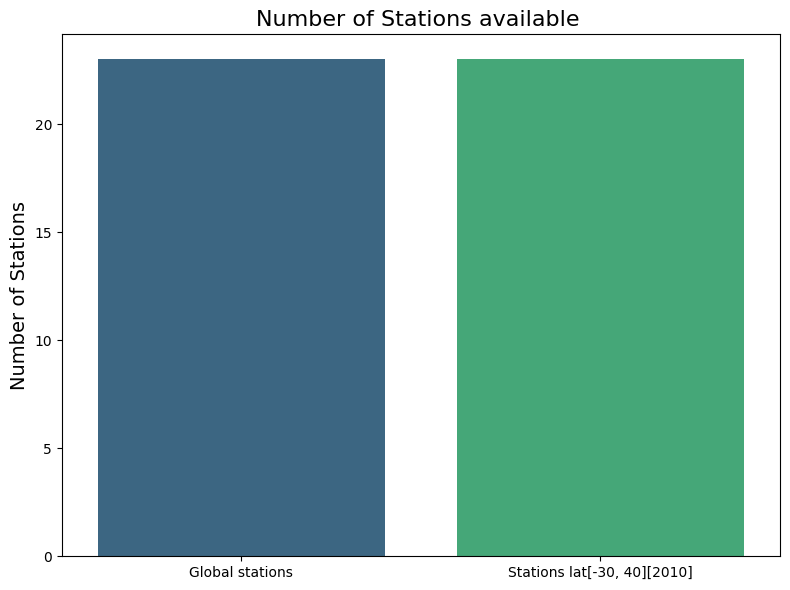

Number of stations before filtering: 23
Number of stations after filtering: 23


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Before filtering
num_stations_before = location_df['STATION NAME'].nunique()
# After filtering
num_stations_after = location_df['STATION NAME'].nunique()

# Plotting both before and after filtering
labels = ['Global stations', 'Stations lat[-30, 40][2010]']
station_counts = [num_stations_before, num_stations_after]

# Plotting
plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=station_counts, palette='viridis')

plt.title('Number of Stations available ', fontsize=16)
# plt.xlabel('Filt', fontsize=14)
plt.ylabel('Number of Stations', fontsize=14)
plt.tight_layout()
plt.savefig("C:\\NOA\\Data\\Demeter_anomaly\stations_list.png")
plt.show()

# Optionally: You can also print the counts for clarity
print(f"Number of stations before filtering: {num_stations_before}")
print(f"Number of stations after filtering: {num_stations_after}")


In [38]:
# coincident_anomalies_df.to_csv(fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\All_window_Station-spatial_matching_98pc_check2.csv")

NameError: name 'coincident_anomalies_df' is not defined

In [40]:
coincident_anomalies_df = pd.read_csv(fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\All_window_Station-spatial_matching_98pc.csv")

In [41]:
coincident_anomalies_df

,Unnamed: 0,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc
0,0,307,[ -5.718 -17.9327],2006-03-15 11:24:32.210,[ -5.718 -17.9327],2006-03-15 11:24:32.210,AS00Q,ASCENSION ISLAND,-7.95,-14.40,462.274825,tw48-30dBG_A,0,val,98
1,1,316,[38.3141 18.3801],2006-03-18 09:28:16.610,[38.3141 18.3801],2006-03-18 09:28:16.610,AT138,ATHENS,38.00,23.50,448.960278,tw48-30dBG_A,0,val,98
2,2,326,[37.7826 19.7498],2006-03-21 09:22:19.443,[37.7826 19.7498],2006-03-21 09:22:19.443,AT138,ATHENS,38.00,23.50,329.953955,tw48-30dBG_A,0,val,98
3,3,377,[37.2528 17.8384],2006-03-31 09:34:46.792,[37.2528 17.8384],2006-03-31 09:34:46.792,AT138,ATHENS,38.00,23.50,505.393358,tw48-30dBG_A,0,val,98
4,4,318,[ 28.1519 -82.4466],2006-03-18 16:03:15.188,[ 28.1519 -82.4466],2006-03-18 16:03:15.188,EG931,EGLIN AFB,30.50,-86.50,471.730634,tw48-30dBG_A,0,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,3112,124,[32.7765 28.6946],2010-10-23 08:02:22.133,[32.7765 28.6946],2010-10-23 08:02:22.133,NI135,NICOSIA,35.03,33.16,482.230556,tw48-30dBG_In-E,19,val,98
3113,3113,37,[ 32.5993 -120.5035],2010-10-07 17:59:41.086,[ 32.5993 -120.5035],2010-10-07 17:59:41.086,PA836,PT ARGUELLO,34.80,-120.50,244.707227,tw48-30dBG_In-E,19,val,98
3114,3114,59,[ 33.0958 -125.9642],2010-10-11 18:21:44.871,[ 33.0958 -125.9642],2010-10-11 18:21:44.871,PA836,PT ARGUELLO,34.80,-120.50,538.374533,tw48-30dBG_In-E,19,val,98
3115,3115,127,[ 31.447 -118.6687],2010-10-23 17:50:45.295,[ 31.447 -118.6687],2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,tw48-30dBG_In-E,19,val,98


In [132]:
combined_df = pd.read_csv(rf"c:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\All_window_Station-spatial_matching_98pc.csv")

In [134]:
df1 = combined_df[combined_df['window']>15]


In [138]:
df1

,Unnamed: 0,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc
233,233,182,[39.1487 27.3226],2010-02-02 08:22:47.230,[39.1487 27.3226],2010-02-02 08:22:47.230,AT138,ATHENS,38.00,23.50,355.972435,tw48-30dBG_A,16,val,98
234,234,399,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,BC840,BOULDER,40.00,-105.30,211.599090,tw48-30dBG_A,16,val,98
235,235,456,[ 37.823 -107.0785],2010-03-21 17:17:43.618,[ 37.823 -107.0785],2010-03-21 17:17:43.618,BC840,BOULDER,40.00,-105.30,286.825436,tw48-30dBG_A,16,val,98
236,236,456,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,EG931,EGLIN AFB,30.50,-86.50,257.034542,tw48-30dBG_A,16,val,98
237,237,318,[ 20.9569 111.1267],2010-02-26 02:32:57.500,[ 20.9569 111.1267],2010-02-26 02:32:57.500,HA419,HAINAN,19.40,109.00,281.484586,tw48-30dBG_A,16,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,3112,124,[32.7765 28.6946],2010-10-23 08:02:22.133,[32.7765 28.6946],2010-10-23 08:02:22.133,NI135,NICOSIA,35.03,33.16,482.230556,tw48-30dBG_In-E,19,val,98
3113,3113,37,[ 32.5993 -120.5035],2010-10-07 17:59:41.086,[ 32.5993 -120.5035],2010-10-07 17:59:41.086,PA836,PT ARGUELLO,34.80,-120.50,244.707227,tw48-30dBG_In-E,19,val,98
3114,3114,59,[ 33.0958 -125.9642],2010-10-11 18:21:44.871,[ 33.0958 -125.9642],2010-10-11 18:21:44.871,PA836,PT ARGUELLO,34.80,-120.50,538.374533,tw48-30dBG_In-E,19,val,98
3115,3115,127,[ 31.447 -118.6687],2010-10-23 17:50:45.295,[ 31.447 -118.6687],2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,tw48-30dBG_In-E,19,val,98


In [139]:
import numpy as np

# Step 1: Drop the model_name column
df_temp = df1.drop(columns=["model_name",'sequence_index']).copy()

# Step 2: Convert list/array columns to tuples (so they become hashable)
for col in df_temp.columns:
    if df_temp[col].apply(lambda x: isinstance(x, (list, np.ndarray))).any():
        df_temp[col] = df_temp[col].apply(
            lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
        )

# Step 3: Remove duplicates
new_df = df_temp.drop_duplicates().reset_index(drop=True)

new_df.head()

,Unnamed: 0,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,window,split,pc
0,233,[39.1487 27.3226],2010-02-02 08:22:47.230,[39.1487 27.3226],2010-02-02 08:22:47.230,AT138,ATHENS,38.0,23.5,355.972435,16,val,98
1,234,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,BC840,BOULDER,40.0,-105.3,211.599090,16,val,98
2,235,[ 37.823 -107.0785],2010-03-21 17:17:43.618,[ 37.823 -107.0785],2010-03-21 17:17:43.618,BC840,BOULDER,40.0,-105.3,286.825436,16,val,98
3,236,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,EG931,EGLIN AFB,30.5,-86.5,257.034542,16,val,98
4,237,[ 20.9569 111.1267],2010-02-26 02:32:57.500,[ 20.9569 111.1267],2010-02-26 02:32:57.500,HA419,HAINAN,19.4,109.0,281.484586,16,val,98


In [156]:
import numpy as np
import pandas as pd

cols = [
    "entry_point", "entry_datetime",
    "exit_point", "exit_datetime",
    "station_id", "station_name",
    "station_lat", "station_lon",
    "min_distance_km",
    "window", "split", "pc"
]

df_unique = df1[cols].copy()

# Convert list/array columns to tuples so drop_duplicates works
for c in ["entry_point", "exit_point"]:
    df_unique[c] = df_unique[c].apply(
        lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
    )

# Ensure datetimes are consistent (optional but recommended)
df_unique["entry_datetime"] = pd.to_datetime(df_unique["entry_datetime"], errors="coerce")
df_unique["exit_datetime"]  = pd.to_datetime(df_unique["exit_datetime"], errors="coerce")

# Drop duplicates using exactly those columns
df_unique = df_unique.drop_duplicates().reset_index(drop=True)

df_unique.head()

,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,window,split,pc
0,[39.1487 27.3226],2010-02-02 08:22:47.230,[39.1487 27.3226],2010-02-02 08:22:47.230,AT138,ATHENS,38.0,23.5,355.972435,16,val,98
1,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,BC840,BOULDER,40.0,-105.3,211.599090,16,val,98
2,[ 37.823 -107.0785],2010-03-21 17:17:43.618,[ 37.823 -107.0785],2010-03-21 17:17:43.618,BC840,BOULDER,40.0,-105.3,286.825436,16,val,98
3,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,EG931,EGLIN AFB,30.5,-86.5,257.034542,16,val,98
4,[ 20.9569 111.1267],2010-02-26 02:32:57.500,[ 20.9569 111.1267],2010-02-26 02:32:57.500,HA419,HAINAN,19.4,109.0,281.484586,16,val,98


In [157]:
df_unique

,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,window,split,pc
0,[39.1487 27.3226],2010-02-02 08:22:47.230,[39.1487 27.3226],2010-02-02 08:22:47.230,AT138,ATHENS,38.00,23.50,355.972435,16,val,98
1,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,BC840,BOULDER,40.00,-105.30,211.599090,16,val,98
2,[ 37.823 -107.0785],2010-03-21 17:17:43.618,[ 37.823 -107.0785],2010-03-21 17:17:43.618,BC840,BOULDER,40.00,-105.30,286.825436,16,val,98
3,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,EG931,EGLIN AFB,30.50,-86.50,257.034542,16,val,98
4,[ 20.9569 111.1267],2010-02-26 02:32:57.500,[ 20.9569 111.1267],2010-02-26 02:32:57.500,HA419,HAINAN,19.40,109.00,281.484586,16,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...
158,[-24.6098 23.9809],2010-01-12 07:55:41.969,[-32.0299 22.116 ],2010-01-12 07:57:44.849,LV12P,LOUISVALE,-28.50,21.20,402.239088,16,val,98
159,[34.9603 37.4048],2010-01-12 07:39:18.606,[34.9603 37.4048],2010-01-12 07:39:18.606,NI135,NICOSIA,35.03,33.16,386.711916,16,val,98
160,[ -6.1684 -18.4 ],2010-09-06 10:48:33.849,[ -6.1684 -18.4 ],2010-09-06 10:48:33.849,AS00Q,ASCENSION ISLAND,-7.95,-14.40,483.807525,18,val,98
161,[38.5 -8.0676],2010-09-06 10:36:16.569,[38.5 -8.0676],2010-09-06 10:36:16.569,EA036,EL ARENOSILLO,37.10,-6.70,196.647081,18,val,98


In [142]:
len(df1['sequence_index'].unique())

106

In [149]:
unique_seq_per_window = (
    df1.groupby("window")["sequence_index"]
       .nunique()
       .reset_index(name="unique_sequence_count")
)

unique_seq_per_window

,window,unique_sequence_count
0,16,29
1,17,43
2,18,14
3,19,26


In [151]:
unique_seq_per_window['unique_sequence_count'].sum()

112

In [153]:
unique_combo_per_seq = (
    df1
    .groupby(["window", "sequence_index"])
    .apply(lambda x: x[["entry_datetime", "station_id"]]
           .drop_duplicates()
           .shape[0])
    .reset_index(name="unique_entry_station_count")
)

unique_combo_per_seq.head()

C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\487648433.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[["entry_datetime", "station_id"]]


,window,sequence_index,unique_entry_station_count
0,16,15,1
1,16,64,3
2,16,69,1
3,16,81,2
4,16,100,1


In [144]:
station_count_per_seq = (
    df1.groupby("sequence_index")["station_id"]
       .nunique()
       .reset_index(name="unique_station_count")
)

station_count_per_seq

,sequence_index,unique_station_count
0,2,1
1,10,1
2,15,1
3,25,4
4,26,1
...,...,...
101,489,1
102,491,3
103,493,1
104,496,2


In [148]:
station_count_per_seq['unique_station_count'].sum()


163

In [140]:
new_df

,Unnamed: 0,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,window,split,pc
0,233,[39.1487 27.3226],2010-02-02 08:22:47.230,[39.1487 27.3226],2010-02-02 08:22:47.230,AT138,ATHENS,38.00,23.50,355.972435,16,val,98
1,234,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,[ 38.1064 -105.0573],2010-03-11 17:10:13.390,BC840,BOULDER,40.00,-105.30,211.599090,16,val,98
2,235,[ 37.823 -107.0785],2010-03-21 17:17:43.618,[ 37.823 -107.0785],2010-03-21 17:17:43.618,BC840,BOULDER,40.00,-105.30,286.825436,16,val,98
3,236,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,[ 28.5407 -85.0903],2010-03-21 15:42:16.471,EG931,EGLIN AFB,30.50,-86.50,257.034542,16,val,98
4,237,[ 20.9569 111.1267],2010-02-26 02:32:57.500,[ 20.9569 111.1267],2010-02-26 02:32:57.500,HA419,HAINAN,19.40,109.00,281.484586,16,val,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...
678,3112,[32.7765 28.6946],2010-10-23 08:02:22.133,[32.7765 28.6946],2010-10-23 08:02:22.133,NI135,NICOSIA,35.03,33.16,482.230556,19,val,98
679,3113,[ 32.5993 -120.5035],2010-10-07 17:59:41.086,[ 32.5993 -120.5035],2010-10-07 17:59:41.086,PA836,PT ARGUELLO,34.80,-120.50,244.707227,19,val,98
680,3114,[ 33.0958 -125.9642],2010-10-11 18:21:44.871,[ 33.0958 -125.9642],2010-10-11 18:21:44.871,PA836,PT ARGUELLO,34.80,-120.50,538.374533,19,val,98
681,3115,[ 31.447 -118.6687],2010-10-23 17:50:45.295,[ 31.447 -118.6687],2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,19,val,98


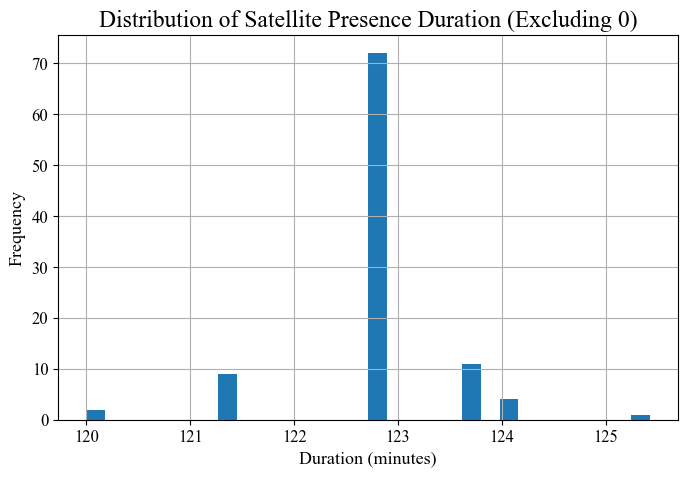

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime format
combined_df["entry_datetime"] = pd.to_datetime(combined_df["entry_datetime"])
combined_df["exit_datetime"] = pd.to_datetime(combined_df["exit_datetime"])

# Compute duration in minutes
combined_df["duration_minutes"] = (
    (combined_df["exit_datetime"] - combined_df["entry_datetime"])
    .dt.total_seconds() )

# Exclude zero or negative durations
duration_clean = combined_df[combined_df["duration_minutes"] > 0]["duration_minutes"]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(duration_clean, bins=30)
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Satellite Presence Duration (Excluding 0)")
plt.grid(True)
plt.show()

In [121]:
combined_df = combined_df[combined_df['window']>15]

C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\3555254521.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


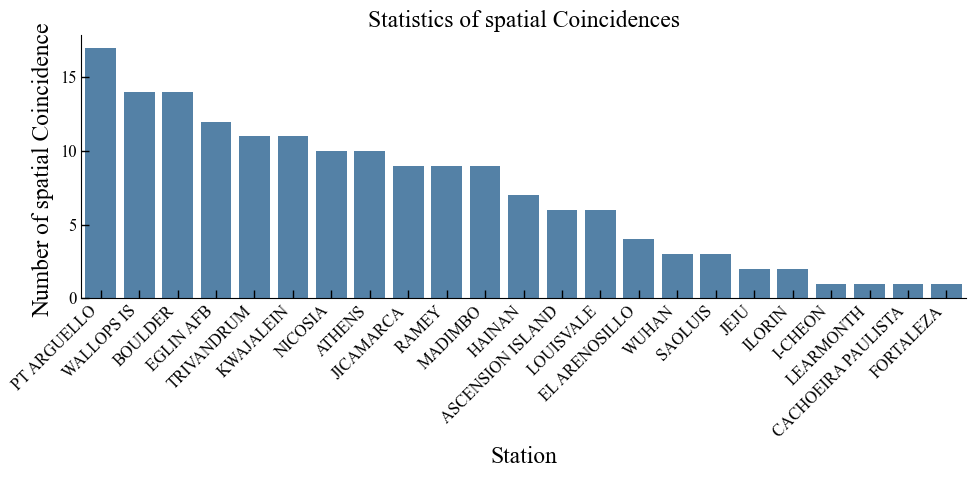

In [158]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -----------------------------
# Prepare data
# -----------------------------
station_counts = (
    df_unique['station_name']
    .value_counts()
    .reset_index()
)

station_counts.columns = ['station_name', 'count']

# Sort by count (descending)
station_counts = station_counts.sort_values(by='count', ascending=False)

# -----------------------------
# Global formatting
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='station_name',
    y='count',
    data=station_counts,
    color='steelblue',
    ax=ax
)

# Titles and labels
ax.set_title("Statistics of spatial Coincidences")
ax.set_xlabel("Station", fontsize =17)
ax.set_ylabel("Number of spatial Coincidence ", fontsize =17)

# Rotate x labels neatly
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Improve ticks (journal style)
ax.tick_params(axis='both', direction='in', length=6, width=1)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save high-resolution
plt.savefig(
    r"C:\PROJECT-DEMETER\Paper1\Plots\NOA\Agg-anomalystations_distribution_unique.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\2893266127.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


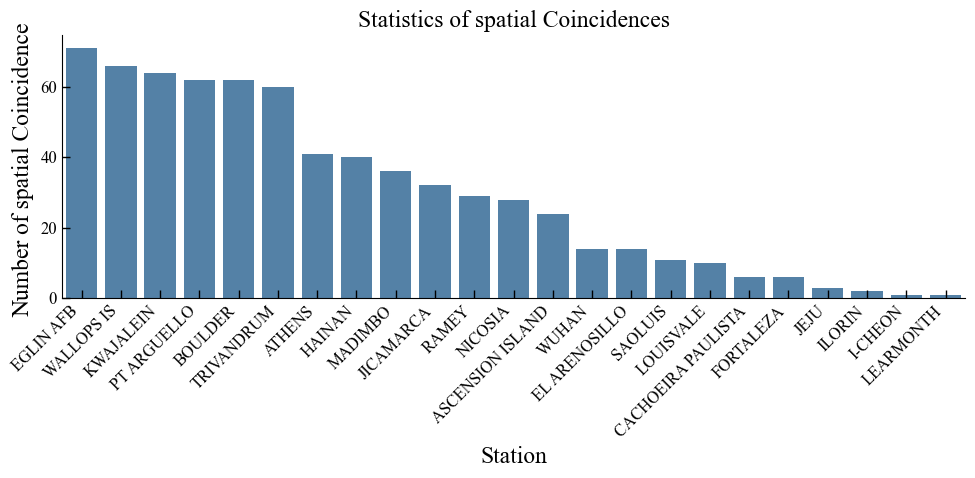

In [122]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -----------------------------
# Prepare data
# -----------------------------
station_counts = (
    combined_df['station_name']
    .value_counts()
    .reset_index()
)

station_counts.columns = ['station_name', 'count']

# Sort by count (descending)
station_counts = station_counts.sort_values(by='count', ascending=False)

# -----------------------------
# Global formatting
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='station_name',
    y='count',
    data=station_counts,
    color='steelblue',
    ax=ax
)

# Titles and labels
ax.set_title("Statistics of spatial Coincidences")
ax.set_xlabel("Station", fontsize =17)
ax.set_ylabel("Number of spatial Coincidence ", fontsize =17)

# Rotate x labels neatly
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Improve ticks (journal style)
ax.tick_params(axis='both', direction='in', length=6, width=1)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save high-resolution
plt.savefig(
    r"C:\PROJECT-DEMETER\Paper1\Plots\NOA\Agg-anomalystations_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


C:\Users\mbabu\AppData\Local\Temp\ipykernel_33556\4213123002.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


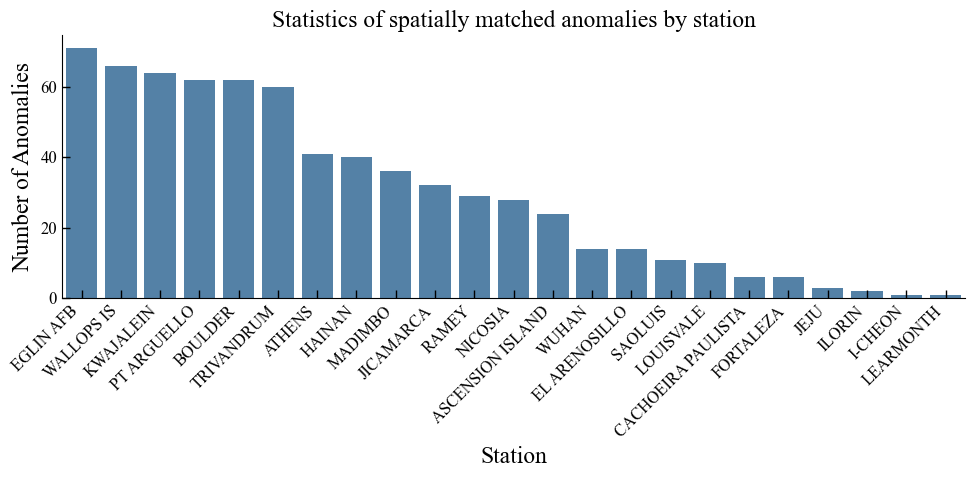

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -----------------------------
# Prepare data
# -----------------------------
station_counts = (
    combined_df['station_name']
    .value_counts()
    .reset_index()
)

station_counts.columns = ['station_name', 'count']

# Sort by count (descending)
station_counts = station_counts.sort_values(by='count', ascending=False)

# -----------------------------
# Global formatting
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='station_name',
    y='count',
    data=station_counts,
    color='steelblue',
    ax=ax
)

# Titles and labels
ax.set_title("Statistics of spatially matched anomalies by station")
ax.set_xlabel("Station", fontsize =17)
ax.set_ylabel("Number of Anomalies", fontsize =17)

# Rotate x labels neatly
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Improve ticks (journal style)
ax.tick_params(axis='both', direction='in', length=6, width=1)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Save high-resolution
plt.savefig(
    # r"C:\PROJECT-DEMETER\Paper1\Plots\NOA\Agg-anomalystations_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


In [ ]:
import pandas as pd

# Load Digisonde data for all stations
digisonde_files = {
    "ATHENS": "C:\\NOA\\Data\\ATHENS\\AT138_2010_n.pkl",
    "ASCENSION ISLAND": "C:\\NOA\\Data\\ASCENSION ISLAND\\AS00Q_2010_n.pkl",
    "MADINMBO": "C:\\NOA\\Data\\MADINMBO\\MU12K_2010_n.pkl",
    "KWAJALEIN": "C:\\NOA\\Data\\KWAJALEIN\\KJ609_2010_n.pkl",
    "JICAMARCA": "C:\\NOA\\Data\\JICAMARCA\\JI91J_2010_n.pkl",
    "HAINAN": "C:\\NOA\\Data\\Anomaly-station\\HA419_2010_n.pkl",
    "EGLIN AFB": "C:\\NOA\\Data\\Anomaly-station\\EG931_2010_n.pkl",
    "EL ARENOSILLO": "C:\\NOA\\Data\\Anomaly-station\\EA036_2010_n.pkl",
    "LOUISVALE": "C:\\NOA\\Data\\Anomaly-station\\LV12P_2010_n.pkl",
    "NICOSIA": "C:\\NOA\\Data\\Anomaly-station\\NI135_2010_n.pkl",
    "BOULDER":"C:\\NOA\\Data\\Anomaly-station\\BC840_2010_n.pkl",
    "RAMEY": "C:\\NOA\\Data\\Anomaly-station\\PRJ18_2010_n.pkl",
    "FORTALEZA": "C:\\NOA\\Data\\Anomaly-station\\FZA0M_2010_n.pkl",
    "CACHOEIRA PAULISTA":"C:\\NOA\\Data\\Anomaly-station\\CAJ2M_2010_n.pkl",
    "I-CHEON":"C:\\NOA\\Data\\Anomaly-station\\IC437_2010_n.pkl",
    "ILORIN": "C:\\NOA\\Data\\Anomaly-station\\IL008_2010_n.pkl",
    "JEJU": "C:\\NOA\\Data\\Anomaly-station\\JJ433_2010_n.pkl",
    "TRIVANDRUM":"C:\\NOA\\Data\\Anomaly-station\\TM308_2010_n.pkl",
    "WUHAN": "C:\\NOA\\Data\\Anomaly-station\\WU430_2010_n.pkl",
    "PT ARGUELLO": "C:\\NOA\\Data\\Anomaly-station\\PA836_2010_n.pkl",
    "SAOLUIS": "C:\\NOA\\Data\\Anomaly-station\\SAA0K_2010_n.pkl",
    "WALLOPS IS": "C:\\NOA\\Data\\Anomaly-station\\WP937_2010_n.pkl",
    "LEARMONTH": "C:\\NOA\\Data\\Anomaly-station\\LM42B_2010_n.pkl",

}

In [ ]:
len(combined_df['station_name'].unique())

23

In [ ]:
import pandas as pd
from datetime import timedelta

SOUNDING_DURATION = 90  # Define your actual sounding duration
 
def find_coincidences(digisonde_data, fb, station):
    # Filter fb to only include the specified station
    station_mask = fb['station_name'] == station
    df = fb.loc[station_mask].copy()  # Work on a copy to avoid modifying slices directly

    for idx, df_point in df.iterrows():
        for _, digisonde_point in digisonde_data.iterrows():
            ts = pd.to_datetime(digisonde_point['sounding_timestamp'])  # Digisonde start time
            te = df_point['entry_datetime']  # Satellite entry time
            tx = df_point['exit_datetime']  # Satellite exit time
            
            if te <= ts + timedelta(seconds=90):
                # Compute extended overlap time if needed
                T_n = max(0, (tx - (ts + timedelta(seconds=SOUNDING_DURATION))).total_seconds()) if tx > (ts + timedelta(seconds=SOUNDING_DURATION)) else 0

                # Compute overlap duration
                To = max(0, (tx - max(ts, te)).total_seconds())

                if To > 0:  # Only update when there is a valid overlap
                    fb.loc[idx, 'Label'] = 1  # Set label in the original DataFrame
                    fb.loc[idx, 'To'] = To    # Store calculated overlap time
                    fb.loc[idx, 'sounding_timestamp']=ts
                    break  # Stop checking once a valid match is found
    
    return fb


In [ ]:
import pandas as pd


# Load all digisonde data into a dictionary
digisonde_data = {station: pd.read_pickle(path) for station, path in digisonde_files.items()}

# Process coincidences for each station
for station, dg_data in digisonde_data.items():
    combined_df= find_coincidences(dg_data, combined_df, station=station)



C:\Users\mbabu\AppData\Local\Temp\ipykernel_31236\1239733949.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fb.loc[idx, 'Label'] = 1  # Set label in the original DataFrame
C:\Users\mbabu\AppData\Local\Temp\ipykernel_31236\1239733949.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fb.loc[idx, 'To'] = To    # Store calculated overlap time
C:\Users\mbabu\AppData\Local\Temp\ipykernel_31236\1239733949.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

In [ ]:
# C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA
# fb= pd.read_pickle('C:\\NOA\\Data\\p1-station\\fb_ST-Coincidnece_all.pkl')
combined_df.to_pickle(fr'C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\ST-Coincidnece_all_model-2010_98pc_check2.pkl')

In [ ]:
combined_df

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc,Label,To,sounding_timestamp
233,182,"[39.1487, 27.3226]",2010-02-02 08:22:47.230,"[39.1487, 27.3226]",2010-02-02 08:22:47.230,AT138,ATHENS,38.00,23.50,355.972435,tw48-30dBG_A,16,val,98,NaN,NaN,NaT
234,399,"[38.1064, -105.0573]",2010-03-11 17:10:13.390,"[38.1064, -105.0573]",2010-03-11 17:10:13.390,BC840,BOULDER,40.00,-105.30,211.599090,tw48-30dBG_A,16,val,98,NaN,NaN,NaT
235,456,"[37.823, -107.07849999999999]",2010-03-21 17:17:43.618,"[37.823, -107.07849999999999]",2010-03-21 17:17:43.618,BC840,BOULDER,40.00,-105.30,286.825436,tw48-30dBG_A,16,val,98,NaN,NaN,NaT
236,456,"[28.5407, -85.09030000000001]",2010-03-21 15:42:16.471,"[28.5407, -85.09030000000001]",2010-03-21 15:42:16.471,EG931,EGLIN AFB,30.50,-86.50,257.034542,tw48-30dBG_A,16,val,98,NaN,NaN,NaT
237,318,"[20.9569, 111.1267]",2010-02-26 02:32:57.500,"[20.9569, 111.1267]",2010-02-26 02:32:57.500,HA419,HAINAN,19.40,109.00,281.484586,tw48-30dBG_A,16,val,98,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,124,"[32.7765, 28.6946]",2010-10-23 08:02:22.133,"[32.7765, 28.6946]",2010-10-23 08:02:22.133,NI135,NICOSIA,35.03,33.16,482.230556,tw48-30dBG_In-E,19,val,98,NaN,NaN,NaT
3113,37,"[32.5993, -120.5035]",2010-10-07 17:59:41.086,"[32.5993, -120.5035]",2010-10-07 17:59:41.086,PA836,PT ARGUELLO,34.80,-120.50,244.707227,tw48-30dBG_In-E,19,val,98,NaN,NaN,NaT
3114,59,"[33.0958, -125.9642]",2010-10-11 18:21:44.871,"[33.0958, -125.9642]",2010-10-11 18:21:44.871,PA836,PT ARGUELLO,34.80,-120.50,538.374533,tw48-30dBG_In-E,19,val,98,NaN,NaN,NaT
3115,127,"[31.447, -118.6687]",2010-10-23 17:50:45.295,"[31.447, -118.6687]",2010-10-23 17:50:45.295,PA836,PT ARGUELLO,34.80,-120.50,409.965691,tw48-30dBG_In-E,19,val,98,NaN,NaN,NaT


In [ ]:
c =combined_df[combined_df["Label"]==1]

In [ ]:
len(c)

21

In [ ]:
c

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc,Label,To,sounding_timestamp
238,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_A,16,val,98,1.0,60.636,2010-03-02 22:35:00
288,214,"[-8.4646, -74.39499999999998]",2010-11-11 14:28:26.976,"[-15.9096, -75.99759999999998]",2010-11-11 14:30:29.856,JI91J,JICAMARCA,-12.0,-76.8,443.264019,tw48-30dBG_A,19,val,98,1.0,29.856,2010-11-11 14:30:00
552,491,"[40.5503, -4.4886000000000195]",2010-03-27 10:29:46.038,"[33.1312, -6.641300000000001]",2010-03-27 10:31:48.918,EA036,EL ARENOSILLO,37.1,-6.7,428.784902,tw48-30dBG_B,16,val,98,1.0,103.918,2010-03-27 10:30:05
555,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_B,16,val,98,1.0,60.636,2010-03-02 22:35:00
579,196,"[13.9266, 167.7483]",2010-05-03 22:39:57.812,"[6.4739, 166.1563]",2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_B,17,val,98,1.0,120.692,2010-05-03 22:40:00
849,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_C,16,val,98,1.0,60.636,2010-03-02 22:35:00
869,196,"[13.9266, 167.7483]",2010-05-03 22:39:57.812,"[6.4739, 166.1563]",2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_C,17,val,98,1.0,120.692,2010-05-03 22:40:00
1175,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_D,16,val,98,1.0,60.636,2010-03-02 22:35:00
1198,196,"[13.9266, 167.7483]",2010-05-03 22:39:57.812,"[6.4739, 166.1563]",2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_D,17,val,98,1.0,120.692,2010-05-03 22:40:00
1530,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_E,16,val,98,1.0,60.636,2010-03-02 22:35:00


In [ ]:
c['station_name'].unique()

array(['KWAJALEIN', 'JICAMARCA', 'EL ARENOSILLO'], dtype=object)

In [ ]:
c

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc,Label,To,sounding_timestamp
238,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_A,16,val,98,1.0,60.636,2010-03-02 22:35:00
288,214,"[-8.4646, -74.39499999999998]",2010-11-11 14:28:26.976,"[-15.9096, -75.99759999999998]",2010-11-11 14:30:29.856,JI91J,JICAMARCA,-12.0,-76.8,443.264019,tw48-30dBG_A,19,val,98,1.0,29.856,2010-11-11 14:30:00
552,491,"[40.5503, -4.4886000000000195]",2010-03-27 10:29:46.038,"[33.1312, -6.641300000000001]",2010-03-27 10:31:48.918,EA036,EL ARENOSILLO,37.1,-6.7,428.784902,tw48-30dBG_B,16,val,98,1.0,103.918,2010-03-27 10:30:05
555,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_B,16,val,98,1.0,60.636,2010-03-02 22:35:00
579,196,"[13.9266, 167.7483]",2010-05-03 22:39:57.812,"[6.4739, 166.1563]",2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_B,17,val,98,1.0,120.692,2010-05-03 22:40:00
849,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_C,16,val,98,1.0,60.636,2010-03-02 22:35:00
869,196,"[13.9266, 167.7483]",2010-05-03 22:39:57.812,"[6.4739, 166.1563]",2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_C,17,val,98,1.0,120.692,2010-05-03 22:40:00
1175,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_D,16,val,98,1.0,60.636,2010-03-02 22:35:00
1198,196,"[13.9266, 167.7483]",2010-05-03 22:39:57.812,"[6.4739, 166.1563]",2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_D,17,val,98,1.0,120.692,2010-05-03 22:40:00
1530,347,"[12.5914, 169.5552]",2010-03-02 22:33:57.756,"[5.1387, 167.9704]",2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_E,16,val,98,1.0,60.636,2010-03-02 22:35:00


C:\Users\mbabu\AppData\Local\Temp\ipykernel_31236\2638868596.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='station_name', y='count', data=station_counts, palette='viridis')


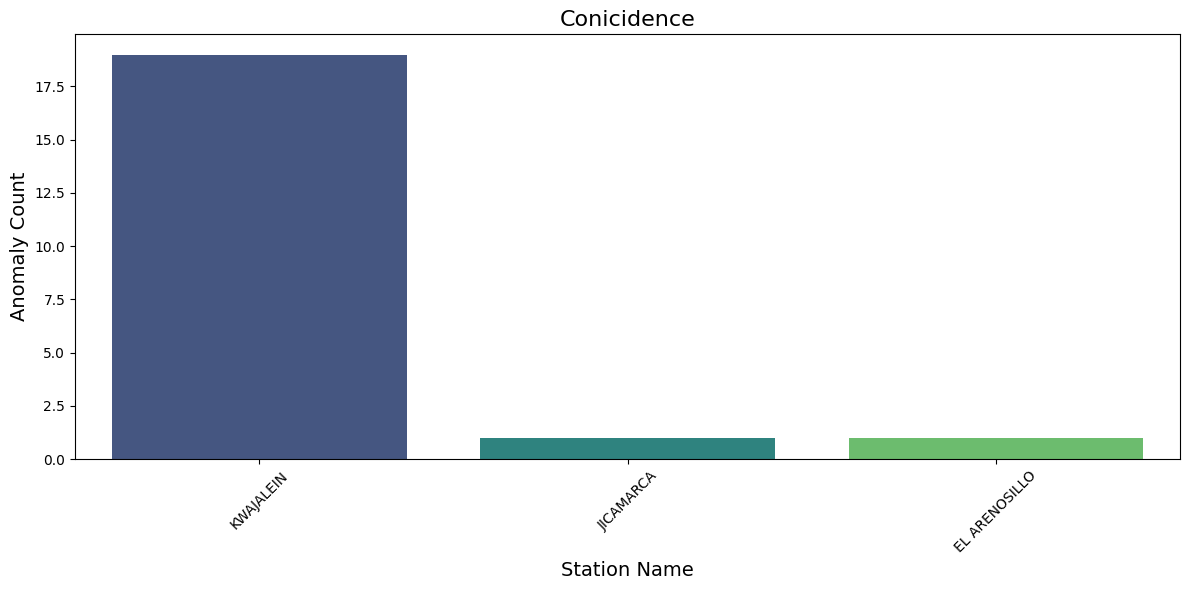

In [ ]:
station_counts = c['station_name'].value_counts().reset_index()
station_counts.columns = ['station_name', 'count']

# Plot the bar chart for station count
plt.figure(figsize=(12, 6))
sns.barplot(x='station_name', y='count', data=station_counts, palette='viridis')

plt.title('Conicidence', fontsize=16)
plt.xlabel('Station Name', fontsize=14)
plt.ylabel('Anomaly Count', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\Agg-anomalystations_distribution_check2.png")

plt.show()

In [ ]:
unique_pairs = c[["sounding_timestamp", "station_name"]].drop_duplicates()


In [ ]:
from pathlib import Path

out_dir = Path(r"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA")
out_dir.mkdir(parents=True, exist_ok=True)
out_file = out_dir / "Anomaly_ionogram_chek2.csv"

# Column order you want in the CSV
cols = [
    "sequence_index",
    "entry_point","entry_datetime",
    "exit_point","exit_datetime",
    "station_id","station_name","station_lat","station_lon",
    "min_distance_km",
    "model_name","window","split","pc",
    "Label","To",
    "sounding_timestamp",
]

c_export = c.copy().reset_index(drop=True)


# (optional) ensure any missing columns exist
for col in cols:
    if col not in c_export.columns:
        c_export[col] = None

c_export.to_csv(out_file, index=False, encoding="utf-8-sig")
print(f"Saved: {out_file}")


Saved: C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\Anomaly_ionogram.csv


In [ ]:
c['sounding_timestamp'].unique()

<DatetimeArray>
['2010-03-02 22:35:00', '2010-11-11 14:30:00', '2010-03-27 10:30:05',
 '2010-05-03 22:40:00', '2010-10-22 22:22:00']
Length: 5, dtype: datetime64[ns]

In [ ]:
unique_pairs

,sounding_timestamp,station_name
238,2010-03-02 22:35:00,KWAJALEIN
288,2010-11-11 14:30:00,JICAMARCA
552,2010-03-27 10:30:05,EL ARENOSILLO
579,2010-05-03 22:40:00,KWAJALEIN
1599,2010-10-22 22:22:00,KWAJALEIN


In [123]:
df  = pd.read_csv(fr"C:\PROJECT-DEMETER\Demeter_Retrain\output_base\Bg_window_data\New_BG\Results_csv\SW22_TW48\NOA\Anomaly_ionogram.csv")

In [124]:
df

,sequence_index,entry_point,entry_datetime,exit_point,exit_datetime,station_id,station_name,station_lat,station_lon,min_distance_km,model_name,window,split,pc,Label,To,sounding_timestamp
0,347,[ 12.5914 169.5552],2010-03-02 22:33:57.756,[ 5.1387 167.9704],2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_A,16,val,98,1.0,60.636,2010-03-02 22:35:00
1,214,[ -8.4646 -74.395 ],2010-11-11 14:28:26.976,[-15.9096 -75.9976],2010-11-11 14:30:29.856,JI91J,JICAMARCA,-12.0,-76.8,443.264019,tw48-30dBG_A,19,val,98,1.0,29.856,2010-11-11 14:30:00
2,491,[40.5503 -4.4886],2010-03-27 10:29:46.038,[33.1312 -6.6413],2010-03-27 10:31:48.918,EA036,EL ARENOSILLO,37.1,-6.7,428.784902,tw48-30dBG_B,16,val,98,1.0,103.918,2010-03-27 10:30:05
3,347,[ 12.5914 169.5552],2010-03-02 22:33:57.756,[ 5.1387 167.9704],2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_B,16,val,98,1.0,60.636,2010-03-02 22:35:00
4,196,[ 13.9266 167.7483],2010-05-03 22:39:57.812,[ 6.4739 166.1563],2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_B,17,val,98,1.0,120.692,2010-05-03 22:40:00
5,347,[ 12.5914 169.5552],2010-03-02 22:33:57.756,[ 5.1387 167.9704],2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_C,16,val,98,1.0,60.636,2010-03-02 22:35:00
6,196,[ 13.9266 167.7483],2010-05-03 22:39:57.812,[ 6.4739 166.1563],2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_C,17,val,98,1.0,120.692,2010-05-03 22:40:00
7,347,[ 12.5914 169.5552],2010-03-02 22:33:57.756,[ 5.1387 167.9704],2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_D,16,val,98,1.0,60.636,2010-03-02 22:35:00
8,196,[ 13.9266 167.7483],2010-05-03 22:39:57.812,[ 6.4739 166.1563],2010-05-03 22:42:00.692,KJ609,KWAJALEIN,9.0,167.2,303.515010,tw48-30dBG_D,17,val,98,1.0,120.692,2010-05-03 22:40:00
9,347,[ 12.5914 169.5552],2010-03-02 22:33:57.756,[ 5.1387 167.9704],2010-03-02 22:36:00.636,KJ609,KWAJALEIN,9.0,167.2,437.689778,tw48-30dBG_E,16,val,98,1.0,60.636,2010-03-02 22:35:00


In [130]:
unique_pairs = df[['station_name', 'sounding_timestamp','To']].drop_duplicates()

In [131]:
unique_pairs

,station_name,sounding_timestamp,To
0,KWAJALEIN,2010-03-02 22:35:00,60.636
1,JICAMARCA,2010-11-11 14:30:00,29.856
2,EL ARENOSILLO,2010-03-27 10:30:05,103.918
4,KWAJALEIN,2010-05-03 22:40:00,120.692
11,KWAJALEIN,2010-10-22 22:22:00,0.613
